Setup và đọc file

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10,6)

df = pd.read_csv("../../data/processed/clean_dataset.csv")
print(df.head())
print(df.info())

            crash_date traffic_control_device weather_condition  \
0  2023-07-29 13:00:00         TRAFFIC SIGNAL             CLEAR   
1  2023-08-13 00:11:00         TRAFFIC SIGNAL             CLEAR   
2  2021-12-09 10:30:00         TRAFFIC SIGNAL             CLEAR   
3  2023-08-09 19:55:00         TRAFFIC SIGNAL             CLEAR   
4  2023-08-19 14:55:00         TRAFFIC SIGNAL             CLEAR   

       lighting_condition first_crash_type trafficway_type  \
0                DAYLIGHT          TURNING     NOT DIVIDED   
1  DARKNESS, LIGHTED ROAD          TURNING        FOUR WAY   
2                DAYLIGHT         REAR END  T-INTERSECTION   
3                DAYLIGHT            ANGLE        FOUR WAY   
4                DAYLIGHT         REAR END  T-INTERSECTION   

            alignment roadway_surface_cond road_defect  \
0  STRAIGHT AND LEVEL              UNKNOWN     UNKNOWN   
1  STRAIGHT AND LEVEL                  DRY  NO DEFECTS   
2  STRAIGHT AND LEVEL                  DRY  NO DEF

#### Phần 1: Tổng quan

1. Phân bố mức độ nghiêm trọng tai nạn

Phân tích phân bố của biến most_severe_injury nhằm hiểu tổng quan mức độ nghiêm trọng của các vụ tai nạn

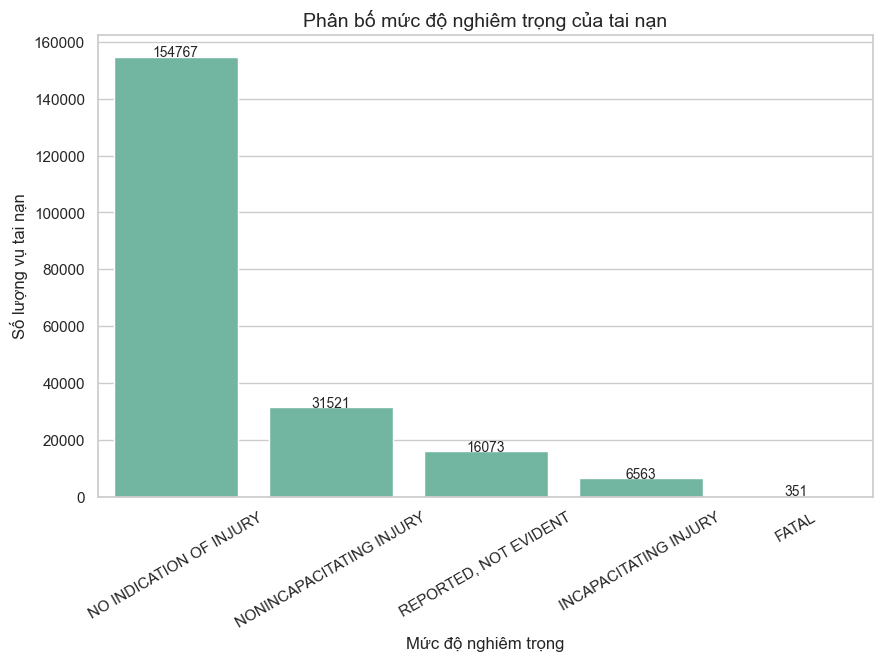

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='most_severe_injury',
    order=df['most_severe_injury'].value_counts().index
)

for index, value in enumerate(df['most_severe_injury'].value_counts()):
    plt.text(index, value + 5, str(value), ha='center', fontsize=10)

plt.title("Phân bố mức độ nghiêm trọng của tai nạn", fontsize=14)
plt.xlabel("Mức độ nghiêm trọng")
plt.ylabel("Số lượng vụ tai nạn")
plt.xticks(rotation=30)

plt.show()

Dữ liệu thống kê:
- Có sự chênh lệch lớn giữa các nhóm. Tổng số vụ tai nạn hơn 209000 vụ
- Các tai nạn không có dấu hiệu chấn thương (NO INDICATION OF INJURY) chiếm đa số với 154767 vụ (khoảng 74%) 
- Nhóm chấn thương nhẹ (NONINCAPACITATING INJURY)  đúng thứ 2 với 31521 vụ, thứ 3 là các vụ tai nạn có báo cáo nhưng không rõ ràng (REPORTED, NOT EVIDENT) với 16073 vụ
- Các vụ tai nạn nghiêm trọng gồm: nhóm dẫn đến tàn tật (INCAPACITATING INJURY) chỉ có 6563 vụ, và nhóm tai nạn chết người (FATAL) chiếm tỷ lệ rất nhỏ với 351 vụ (chưa đến 0.2%)

Nhận xét:
- Tuy mặt nhìn thấy được là phần lớn các vụ tai nạn đều là va chạm nhẹ không gây thương tích (với 154767 vụ, và chiếm khoảng 74%). Nhưng nếu xét về mặt thực tế, đây chính là nguyên nhân hàng đầu gây ùn tắc giao thông dây chuyền và thiệt hại kinh tế gián tiếp với chi phí sửa chữa hoặc thời gian chờ đợi của xã hội.
- Tỷ lệ tử vong cực thấp (khoảng 0.17%) có thể gây ra tâm lý chủ quan. Nhưng thực tế, đây là những vụ tai nạn hiểu nhưng hậu quả thảm khốc -> Đây được coi là điểm mù của dữ liệu.
- Có sự chênh lệch rất lớn giữa lớp “No Jujury” và “Fatal”. Nếu đưa trực tiếp và mô hình, thì máy học chỉ cần đoán mọi vụ tai nạn đều là “No Injury” thì Accuracy vẫn có thể đạt cao -> Mô hình thất bại trong việc nhận diện các vụ tai nạn nghiêm trọng.

2. Phân bố tai nạn theo giờ

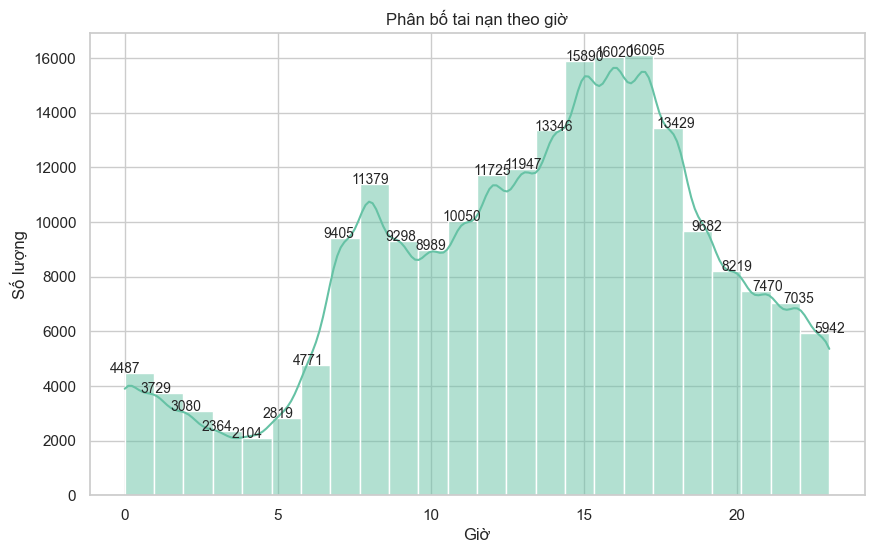

In [3]:
sns.histplot(df['crash_hour'], bins=24, kde=True)

hist_data = df['crash_hour'].value_counts().sort_index()
for hour, count in hist_data.items():
    plt.text(hour, count + 5, str(count), ha='center', fontsize=10)

plt.title("Phân bố tai nạn theo giờ")
plt.xlabel("Giờ")
plt.ylabel("Số lượng")
plt.show()

Dữ liệu thống kê:
- Biểu đồ có dạng “hai đỉnh” rõ rết, tương ứng với hai khoảng thời gian cao điểm trong ngày.
- Đỉnh cao nhất rơi vào khung giờ từ 15-17h, đạt cực đại vào lúc 16h (16020 vụ) và 17h (16095 vụ) -> Đây là thời điểm có số lượng tai nạn cao nhất trong ngày
- Đỉnh phụ xuất hiện vào buổi sáng từ 7-9h, với đỉnh điểm lúc 8h (11379 vụ)
Điểm thấp nhất rơi vào khoảng 3-4h sáng (chỉ còn khoảng 2104 vụ), sau đó bắt đầu tăng nhanh từ 5h sáng

Nhận xét:
- Có thể thấy các thời điểm nhiều vụ tai nạn xảy ra nhất là vào các giờ cao điểm, nghĩa là tai nạn tỷ lệ thuận với mật độ giao thông. Tuy nhiên, đỉnh điểm buổi chiều cao hơn đỉnh điểm buổi sáng. Lý do có thể là ngoài áp lực về mật độ, thì chiều là khoảng thời gian người dân tan làm, tan học trong trạng thái mệt mỏi, và mang tâm lý muốn về nhà thật nhanh, đồng thời ánh sáng buổi chiều (chạng vạng) có thể làm giảm tầm nhìn
- Số vụ tai nạn thấp nhất vào rạng sáng không có nghĩa là lái xe an toàn hơn vào thời điểm này, mà chủ yếu là do lưu lượng xe thấp
- Ngoài ra, có thể thấy các vụ tai nạn về ban đêm tuy ít nhưng lại có tỷ lệ tử vong cao hơn do tốc độ và thiếu ánh sáng -> Yếu tố thời gian không chỉ phản ánh lưu lượng giao thông mà còn gián tiếp liên quan đến điều kiện môi trường (ánh sáng)

3. Theo ngày trong tuần

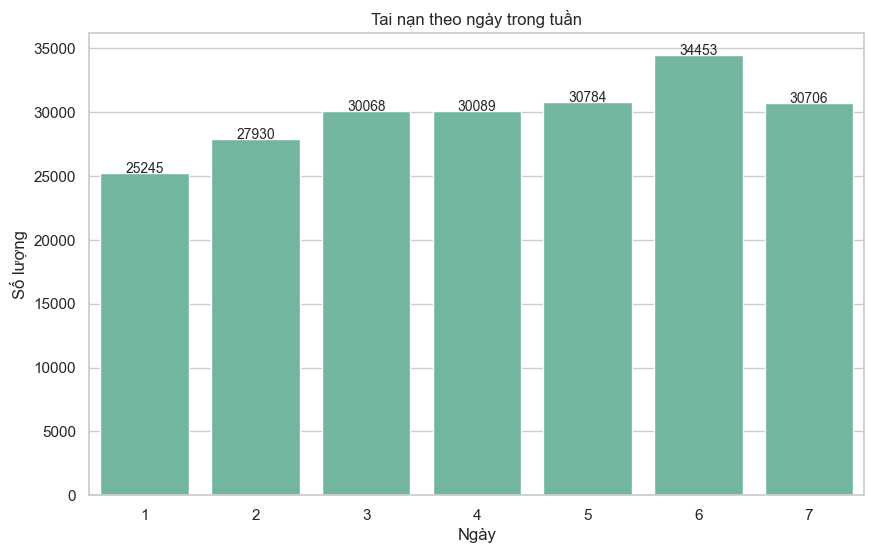

In [ ]:
sns.countplot(data=df, x='crash_day_of_week')

# thêm số lượng lên trên mỗi cột
counts = df['crash_day_of_week'].value_counts().sort_index()
for index, value in counts.items():
    plt.text(index - 0.1, value + 5, str(value), ha='center', fontsize=10)

plt.title("Tai nạn theo ngày trong tuần")
plt.xlabel("Ngày")
plt.ylabel("Số lượng")
plt.show()

Dữ liệu thống kê:
- Cao nhất vào Thứ 7 với 34453 vụ, cao hơn hẳn so với các ngày còn lại
- Các ngày cao điểm khác Chủ nhật và Thứ sáu bám sát nhau với hơn 30000 vụ
- Thấp nhất vào Thứ hai với 25245 vụ, các ngày giữa tuần duy trì ở mức trung bình ổn định quanh mốc 2800-30000 vụ

Nhận xét:
- Số lượng các vụ tai nạn cao nhất vào cuối tuần, hay nói cách khác là “hiệu ứng cuối tuần”. Thay vì đi theo lộ trình đi làm/về nhà cố định như trong tuần, người dân di chuyển nhiều hơn có mục đích giải trí, du lịch
- Đặc biệt, cuối tuần thường là ngày của các buổi tiệc tùng. Vì vậy, sự gia tăng tai nạn có thể liên quan đến việc lái xe sau khi sử dụng rượu bia hoặc di chuyển vào các khung giờ khuya trên những đoạn đường lạ
- Thông thường, Thứ hai đầu tuần sẽ hỗn loạn nhất nhưng dữ liệu lại cho thấy nó an toàn nhất, tạo nên một “nghịch lý Thứ hai”. Có thể do tâm lý bắt đầu tuần mới khiến người lái xe thận trọng hơn, hoặc lưu lượng xe chưa đạt mức tối đa như giữa tuần

4. Phân bố theo thời tiết

In [5]:
top_weather = df['weather_condition'].value_counts()

top_weather 

weather_condition
CLEAR                       164673
RAIN                         21702
CLOUDY/OVERCAST               7532
SNOW                          6869
UNKNOWN                       6534
OTHER                          627
FREEZING RAIN/DRIZZLE          510
FOG/SMOKE/HAZE                 360
SLEET/HAIL                     308
BLOWING SNOW                   127
SEVERE CROSS WIND GATE          32
BLOWING SAND, SOIL, DIRT         1
Name: count, dtype: int64

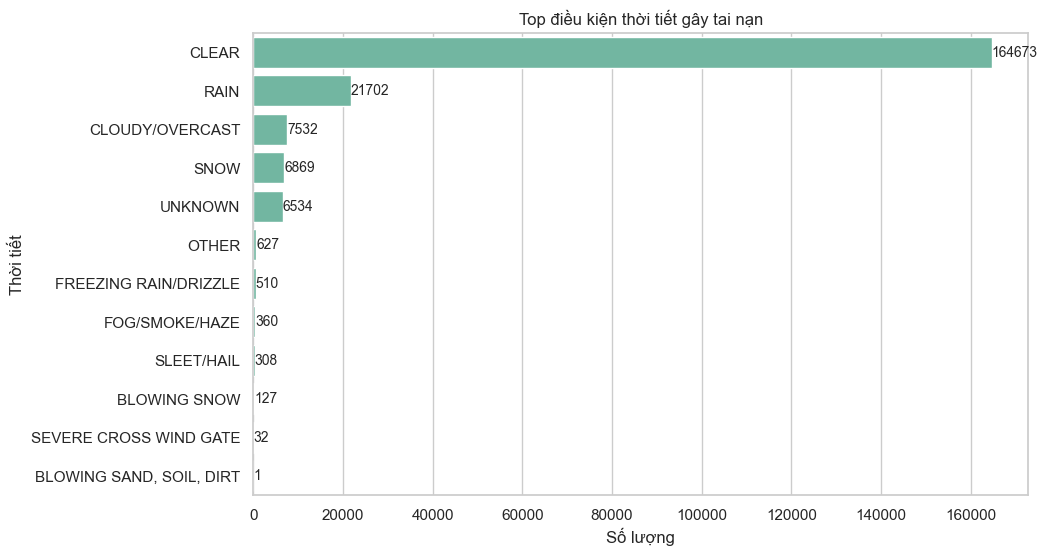

In [6]:
sns.barplot(x=top_weather.values, y=top_weather.index)

for index, value in enumerate(top_weather.values):
    plt.text(value + 5, index, str(value), va='center', fontsize=10)

plt.title("Top điều kiện thời tiết gây tai nạn")
plt.xlabel("Số lượng")
plt.ylabel("Thời tiết")
plt.show()

Dữ liệu thống kê:
- Thời tiết đẹp (CLEAR) chiếm tỷ lệ áp đảo với 164673 vụ (chiếm khoảng 78% tổng số vụ)
- Thời tiết xấu đứng thứ hai là Mưa (RAIN) với 21702 vụ
- Các điều kiện khác như Tuyết (SNOW), Mây mù (CLOUDY) chiếm tỷ trọng rất thấp

Nhận xét:
- Phần lớn tai nạn lại xảy ra khi thời tiết đẹp. Điều này có thể do người lái xe cảm thấy chủ quan, dễ chạy nhanh hoặc mất tập trung khi tầm nhìn tốt. Ngược lại, khi thời tiết xấu như mưa hay tuyết, mọi người thường cẩn thận hơn hoặc ít ra đường hơn, nên số vụ tai nạn giảm
- Đề xuất: Các chương trình an toàn giao thông không chỉ nên tập trung cảnh báo khi thời tiết xấu, mà cần nhấn mạnh việc luôn giữ sự tập trung và lái xe an toàn ngay cả khi điều kiện thời tiết bình thường

5. Phân bố theo ánh sáng

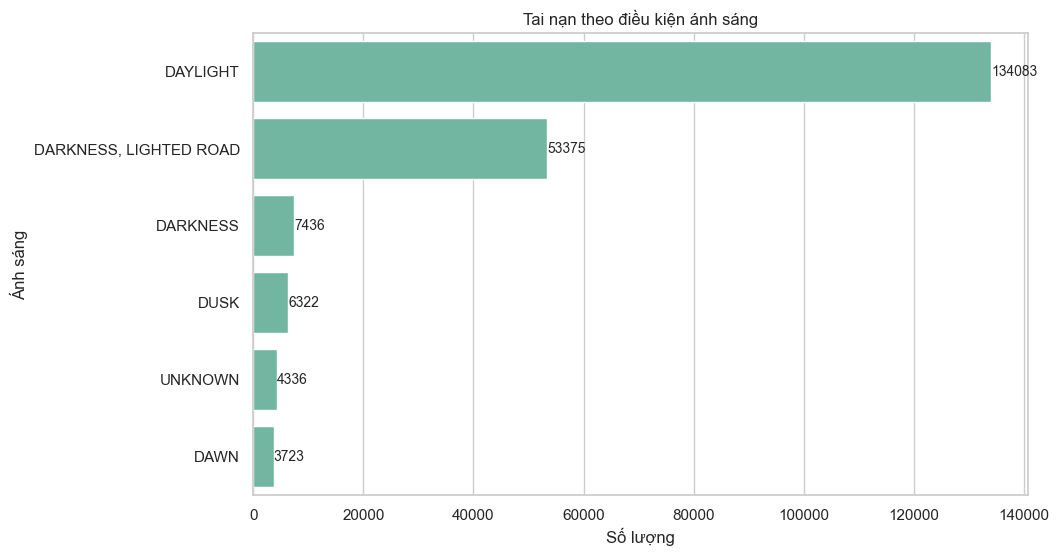

In [7]:
sns.countplot(data=df, y='lighting_condition',
              order=df['lighting_condition'].value_counts().index)

for index, value in enumerate(df['lighting_condition'].value_counts()):
    plt.text(value + 5, index, str(value), va='center', fontsize=10)

plt.title("Tai nạn theo điều kiện ánh sáng")
plt.xlabel("Số lượng")
plt.ylabel("Ánh sáng")
plt.show()

Dữ liệu thống kê:
- Phần lớn tai nạn xảy ra vào ban ngày (DAYLIGHT) với 134083 vụ (khoảng 64%)
- Đáng chú ý là điều kiện ban đêm có đèn đường (DARKNESS, LIGHTED ROAD) chiếm tới 53378 vụ, cao gấp 7 lần so với ban đêm không đèn (DARKNESS - 7436 vụ)

Nhận xét:
- Số vụ ban ngày cao do đây là thời điểm mật độ phương tiện lưu thông cao nhất. Tuy nhiên các vụ này thường tập trung ở nhóm va chạm nhẹ do tốc độ di chuyển trong đô thị vào ban ngày thường bị hạn chế bởi ùn tắc
- Việc tai nạn tại các đoạn đường có đèn cao gấp 7 lần so với đường không đèn không có nghĩa là đèn đường gây nguy hiểm. Nó phản ánh rằng các khu vực trung tâm, giao lộ phức tạp và điểm đen giao thông thường được lắp đèn, nhưng chính sự phức tạp về luồng xe và sự chủ quan của tài xế dưới ánh sáng nhân tạo đã dẫn đến tai nạn
- Khoảng thời gian nhạy cảm: Chạng vạng (Dusk) và rạng đông (Dawn) tuy số lượng ít nhưng là lúc mắt người khó thích nghi với ánh sáng, làm giảm khả năng ước lượng khoảng cách và nhận diện chướng ngại vật

6. Phân bố theo tình trạng mặt đường

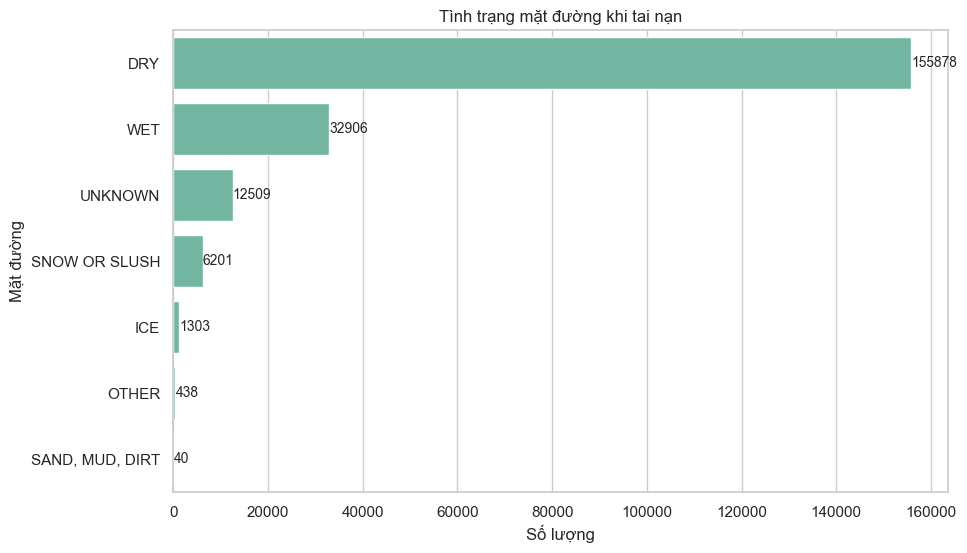

In [8]:
sns.countplot(data=df, y='roadway_surface_cond',
              order=df['roadway_surface_cond'].value_counts().index)

for index, value in enumerate(df['roadway_surface_cond'].value_counts()):
    plt.text(value + 5, index, str(value), va='center', fontsize=10)

plt.title("Tình trạng mặt đường khi tai nạn")
plt.xlabel("Số lượng")
plt.ylabel("Mặt đường")
plt.show()

Dữ liệu thống kê:
- Mặt đường khô ráo (DRY) chiếm phần lớn với 155878 vụ (chiếm khoảng 75% tổng số vụ)
- Mặt đường ướt (WET) đứng thứ 2 với 32906 vụ (khoảng 15%)
- Nhóm đường đóng băng (ICE) và tuyết/bùn tuyết (SNOW OR SLUSH) chiếm tỷ lệ nhỏ nhưng đáng kể (khoảng 3-4%), tập trung vào các tháng mùa đông
- Dữ liệu UNKNOWN được ghi nhận với số lượng đáng kể, gây khó khăn cho việc phân tích chính xác các yếu tố môi trường tại hiện trường

Nhận xét:
- Điều kiện “khô ráo” không đồng nghĩa với an toàn tuyệt đối: Dù mặt đường khô và thời tiết đẹp chiếm đa số tai nạn, điều này cho thấy tai nạn không chỉ phụ thuộc vào điều kiện môi trường mà còn liên quan mạnh đến hành vi người lái (chủ quan, tốc độ, mất tập trung) -> Sự an toàn của hạ tầng tỷ lệ nghịch với sự tập trung của người lái
- Đối với nhóm đường WET, nguy cơ không chỉ đến từ việc đường trơn mà còn từ hiện tượng trượt nước – khi bánh xe mất độ bám hoàn toàn. Dữ liệu này cho thấy các vụ tai nạn khi đường ướt thường xảy ra ở các khúc cua hoặc điểm cần phanh gấp
- Kết hợp với biểu đồ thời tiết, ta thấy sự đồng nhất giữa "Clear" và "Dry". Điều này khẳng định yếu tố môi trường trong tập dữ liệu này đóng vai trò "nền tảng", còn hành vi mới là "biến số" gây ra tai nạn

7. Tỷ lệ tai nạn tại giao lộ

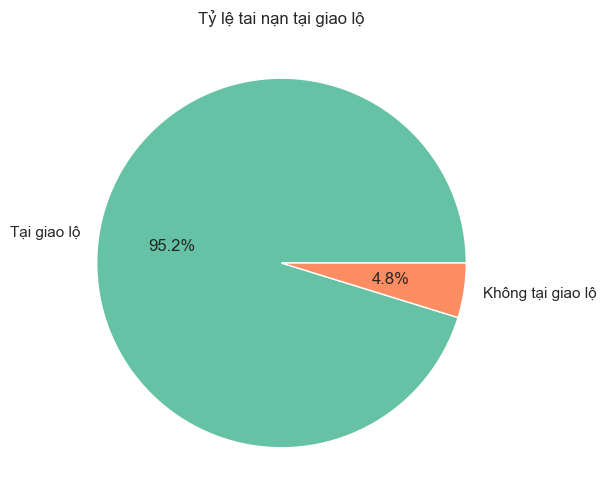

In [9]:
df['intersection_related_i'].map({0: 'Không tại giao lộ', 1: 'Tại giao lộ'}).value_counts().plot.pie(autopct='%1.1f%%')

plt.title("Tỷ lệ tai nạn tại giao lộ")
plt.ylabel("")
plt.show()

Dữ liệu thống kê:
- Có tới 95.2% số vụ tai nạn xảy ra tại giao lộ (Intersection), chiếm tỷ lệ áp đảo
- Chỉ có 4.8% vụ tai nạn xảy ra ở các đoạn đường thẳng hoặc không thuộc khu vực giao cắt

Nhận xét:
- Giao lộ là nơi các luồng xe giao nhau và chuyển hướng liên tục, đòi hỏi người lái phải tập trung cao. Tỷ lệ 95.2% cho thấy giao lộ chính là khu vực có rủi ro tai nạn cao nhất trong dữ liệu, giống như “điểm nóng” của an toàn giao thông
- Tỷ lệ rất cao này thường gắn với các khu vực đô thị đông đúc, nơi có nhiều nút giao dày đặc. Điều đó gợi ý rằng việc cải thiện hạ tầng tại giao lộ (như đèn tín hiệu, vòng xuyến, phân luồng rõ ràng) sẽ mang lại hiệu quả giảm tai nạn rõ rệt hơn so với chỉ nâng cấp các đoạn đường thẳng

8. Nguyên nhân tại nạn phổ biến

In [10]:
top_causes = df['prim_contributory_cause'].value_counts().head(10)

top_causes

prim_contributory_cause
UNKNOWN                                   58310
FAILING TO YIELD RIGHT-OF-WAY             42909
FOLLOWING TOO CLOSELY                     19074
DISREGARDING TRAFFIC SIGNALS              14590
IMPROPER TURNING/NO SIGNAL                12642
FAILING TO REDUCE SPEED TO AVOID CRASH    10675
IMPROPER OVERTAKING/PASSING                8302
DISREGARDING STOP SIGN                     6746
IMPROPER LANE USAGE                        6460
NOT APPLICABLE                             5241
Name: count, dtype: int64

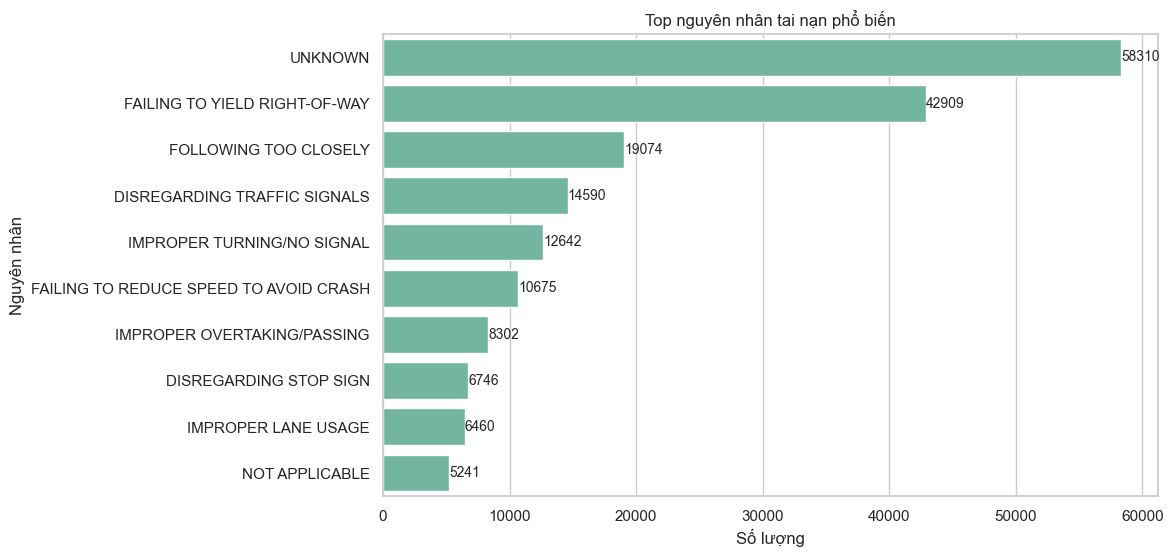

In [11]:
sns.barplot(x=top_causes.values, y=top_causes.index)
for index, value in enumerate(top_causes.values):
    plt.text(value + 5, index, str(value), va='center', fontsize=10)
plt.title("Top nguyên nhân tai nạn phổ biến")
plt.xlabel("Số lượng")
plt.ylabel("Nguyên nhân")
plt.show()

Dữ liệu thống kê:
- Dữ liệu có 1 vấn đề khá nghiêm trọng, nhóm “UNKNOWN” chiếm nhiều nhất với 58310 vụ, cho thấy việc ghi nhận nguyên nhân tại hiện trường còn gặp nhiều hạn chế
- Lỗi hành vi phổ biến nhất: “FAILING TO YIELD RIGHT-OF-WAY” (không nhường đường ưu tiên) đứng đầu với 42909 vụ
- Các lỗi phổ biến khác: “FOLLOWING TOO CLOSELY” (bám đuôi quá sát) với 19074 vụ và “DISREGARDING TRAFFIC SIGNALS” (không tuân thủ tín hiệu giao thông) với 14590 vụ


Nhận xét:
- Lỗi không nhường đường chiếm tỷ lệ cao, phản ánh việc nhiều tài xế có xu hướng tranh chấp quyền đi, đặc biệt tại các nút giao — phù hợp với nhận định tai nạn thường tập trung ở giao lộ
- Lỗi bám đuôi quá sát thường là hệ quả của tình trạng ùn tắc giao thông và áp lực di chuyển nhanh trong giờ cao điểm. Khi khoảng cách an toàn bị rút ngắn, khả năng phản ứng của tài xế trước các tình huống bất ngờ gần như bằng không
- Dù số vụ vượt đèn tín hiệu ít hơn lỗi nhường đường, nhưng đây lại là nguyên nhân chính dẫn đến các vụ va chạm góc

9. Loại tai nạn phổ biến

In [12]:
top_crash = df['first_crash_type'].value_counts().head(10)
top_crash

first_crash_type
TURNING                         64150
ANGLE                           52243
REAR END                        42007
SIDESWIPE SAME DIRECTION        20114
PEDESTRIAN                       8995
PEDALCYCLIST                     5335
PARKED MOTOR VEHICLE             4892
FIXED OBJECT                     4742
SIDESWIPE OPPOSITE DIRECTION     1839
HEAD ON                          1790
Name: count, dtype: int64

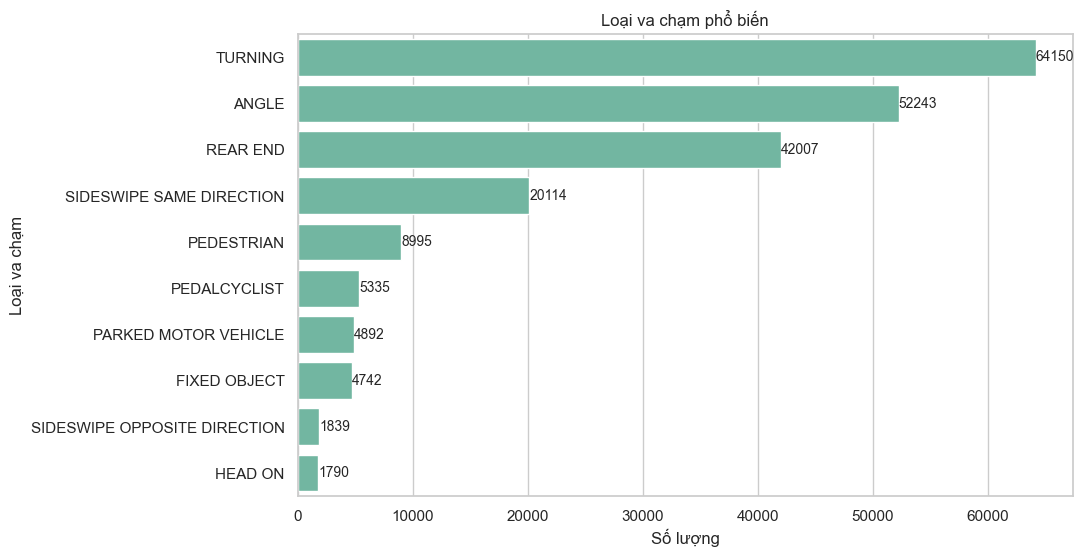

In [13]:
sns.barplot(x=top_crash.values, y=top_crash.index)
for index, value in enumerate(top_crash.values):
    plt.text(value + 5, index, str(value), va='center', fontsize=10)

plt.title("Loại va chạm phổ biến")
plt.xlabel("Số lượng")
plt.ylabel("Loại va chạm")
plt.show()

Dữ liệu thống kê:
- Dẫn đầu là "TURNING" (Tai nạn khi đang rẽ) chiếm cao nhất với 64150 vụ
- Thứ hai và thứ  ba là "ANGLE" (Va chạm góc - 52243 vụ) và "REAR END" (Đâm đuôi xe - 42007 vụ)
- Nhóm nguy hiểm là va chạm với người đi bộ (PEDESTRIAN) và người đi xe đạp (PEDALCYCLIST) tuy số lượng ít hơn (khoảng 14000 vụ) nhưng thường là nhóm có độ nghiêm trọng cao
- Các va chạm như đâm vào vật cố định (Fixed object) hay va chạm hông cùng chiều (Sideswipe) chiếm tỷ lệ nhỏ hơn


Nhận xét:
- Con số Turning và Angle dẫn đầu là minh chứng thực tế cho việc hạ tầng đang bị quá tải tại các điểm giao cắt. Khi xe cộ tập trung quá đông tại giao lộ, việc rẽ trái hoặc rẽ phải trở thành "cuộc chiến" về không gian, dẫn đến va chạm xảy ra liên tục
- Khác với đâm đuôi (có đầu xe bảo vệ), va chạm góc thường đánh trực diện vào phần hông xe – nơi có ít cấu trúc hấp thụ xung lực nhất
- Có một "chuỗi kịch bản" rõ rệt trong dữ liệu: Giao lộ (Vị trí) -> Không nhường đường (Hành vi) -> Turning/Angle (Hậu quả vật lý)

#### Phần 2: Ảnh hưởng (đa chiều)

1. Loại đường và loại va chạm ảnh hưởng đến mức độ nghiêm trọng

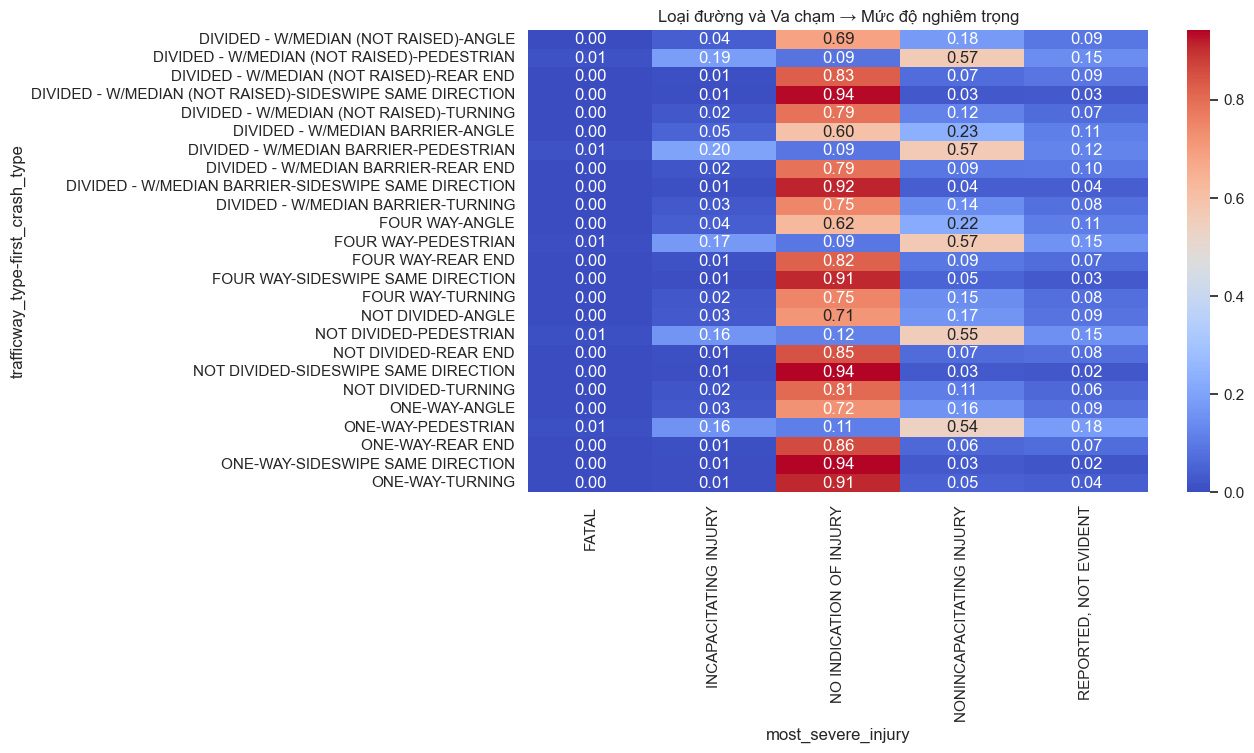

In [14]:
top_road = df['trafficway_type'].value_counts().head(5).index
top_crash = df['first_crash_type'].value_counts().head(5).index

filtered = df[
    (df['trafficway_type'].isin(top_road)) &
    (df['first_crash_type'].isin(top_crash))
]

cross = pd.crosstab(
    [filtered['trafficway_type'], filtered['first_crash_type']],
    filtered['most_severe_injury'],
    normalize='index'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    cross,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Loại đường và Va chạm → Mức độ nghiêm trọng")
plt.show()

Dữ liệu thống kê:
- Nhóm nguy cơ thấp (Tỷ lệ không chấn thương chiếm 82 - 94%):
  + Va chạm đâm đuôi (REAR END) và va chạm cùng chiều (SIDESWIPE) đạt tỷ lệ an toàn cao nhất trên mọi loại đường
  + Đường một chiều (ONE-WAY) cho thấy mức độ an toàn ổn định nhất (85 - 92%) do luồng giao thông ít xung đột
- Nhóm nguy cơ trung bình (Tỷ lệ không chấn thương chiếm 70 - 80%):
  + Va chạm góc (ANGLE) và va chạm khi rẽ (TURNING) có tỷ lệ chấn thương dao động từ 19 - 25%
  + Sự kết hợp giữa ANGLE và đường có dải phân cách (DIVIDED) vẫn tiềm ẩn rủi ro chấn thương khoảng 25%
- Nhóm nguy cơ cực cao (Tỷ lệ chấn thương >70%):
  + Tất cả va chạm liên quan đến người đi bộ (PEDESTRIAN) đều có tỷ lệ thương vong vượt quá 70%
  + Chỉ số chấn thương tàn tật (Incapacitating Injury) ở nhóm này cao nhất toàn bảng (đạt mức 16 - 20%)

Nhận xét:
- Mức độ nghiêm trọng của tai nạn phụ thuộc chủ yếu vào loại va chạm như đâm trực diện, va chạm góc,... hơn là loại đường. Yếu tố này chi phối mức độ nghiêm trọng
- Tai nạn liên quan đến người đi bộ nguy hiểm hơn rất nhiều, với tỷ lệ thương vong cao gấp khoảng 8 lần so với va chạm xe với xe -> Người đi bộ rất dễ bị tổn thương
- Dải phân cách không thật sự hiệu quả, dù giúp giảm va chạm đối đầu nhưng không ngăn được va chạm góc tại giao lộ, nơi xe rẽ và thường chạy nhanh hơn
- Để giảm sự nguy hiểm khi tham gia giao thông nên tách luồng người đi bộ lên cầu vượt hoặc xuống hầm thay vì chỉ biến báo, ngoài ra tại giao lộ nên thêm các gờ giảm tốc để ép xe chạy chậm lại

2. Giao lộ và thiết bị điều khiển đến mức độ nghiêm trọng

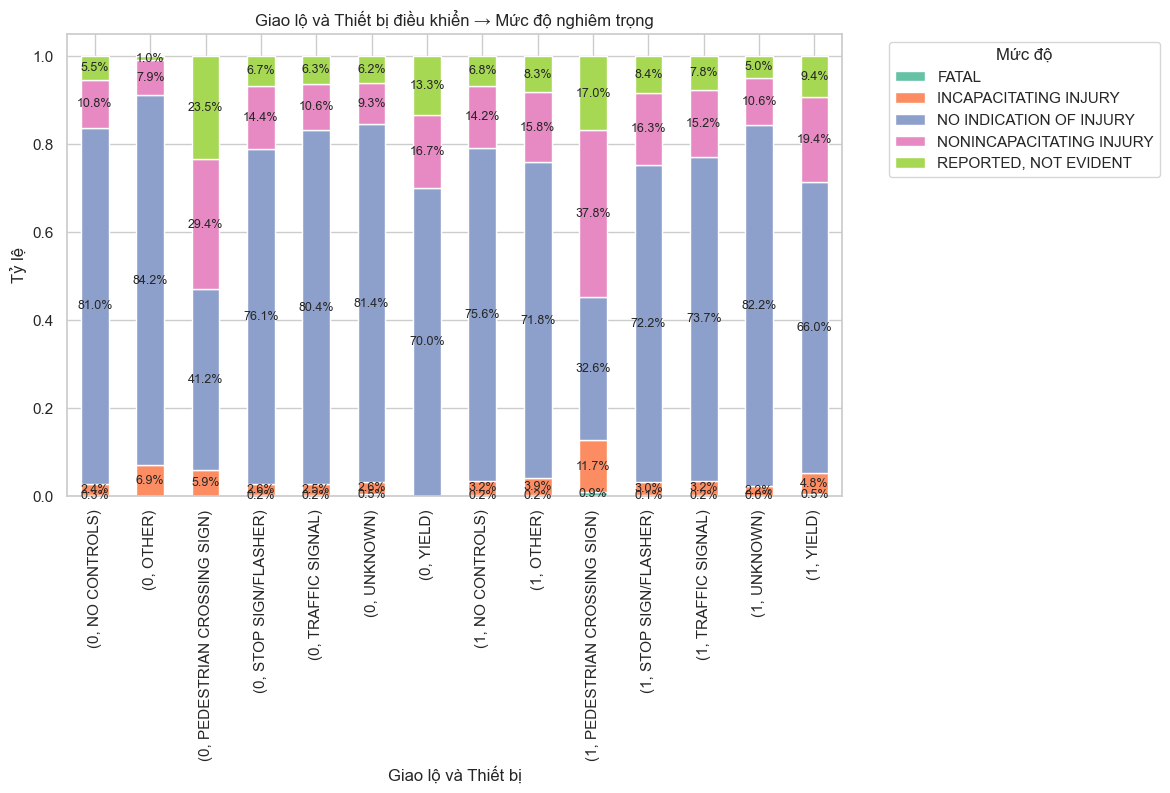

In [15]:
top_control = df['traffic_control_device'].value_counts().head(7).index

filtered = df[df['traffic_control_device'].isin(top_control)]

cross = pd.crosstab(
    [filtered['intersection_related_i'], filtered['traffic_control_device']],
    filtered['most_severe_injury'],
    normalize='index'
)

cross.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

# Thêm tỷ lệ lên trên mỗi phần của cột
for i in range(cross.shape[0]):
    cumulative = 0
    for j in range(cross.shape[1]):
        value = cross.iloc[i, j]
        if value > 0:
            plt.text(i, cumulative + value / 2, f"{value:.1%}", ha='center', va='center', fontsize=9)
            cumulative += value

plt.title("Giao lộ và Thiết bị điều khiển → Mức độ nghiêm trọng")
plt.xlabel("Giao lộ và Thiết bị")
plt.ylabel("Tỷ lệ")
plt.legend(title="Mức độ", bbox_to_anchor=(1.05,1))

plt.show()

Dữ liệu thống kê:
- Khu vực ngoài giao lộ có tỷ lệ không chấn thương cao khoảng 75–80%, gần như không phụ thuộc vào việc có thiết bị điều khiển
- Tại giao lộ, đèn tín hiệu có tỷ lệ không chấn thương cao nhất (78–80%). Biển dừng (Stop Sign) có tỷ lệ không chấn thương ở mức 75–77%
- Giao lộ không có điều khiển (No Control) có tỷ lệ không chấn thương giảm còn 72–74%, tương đương tỷ lệ chấn thương 23–25%
- Biển người đi bộ (Pedestrian Crossing Sign) có tỷ lệ không chấn thương thấp nhất, chỉ khoảng 50%
- Tại khu vực có biển người đi bộ, tỷ lệ chấn thương nhẹ khoảng 37.8% và chấn thương nặng khoảng 11.7%

Nhận xét:
- Mức độ an toàn phụ thuộc mạnh vào loại điều khiển giao thông, trong đó các hình thức mang tính bắt buộc (đèn tín hiệu) giúp giảm rõ rệt tỷ lệ thương vong
- Khi an toàn giao thông phụ thuộc vào ý thức cá nhân (biển báo), rủi ro tai nạn tăng đáng kể
- Sự chênh lệch lớn về tỷ lệ thương vong giữa đèn tín hiệu và biển người đi bộ cho thấy vai trò quan trọng của việc kiểm soát hành vi thay vì chỉ nhắc nhở
- Tại khu vực có biển người đi bộ, tồn tại sự lệch pha nhận thức giữa người đi bộ và tài xế, làm tăng nguy cơ va chạm nguy hiểm
- Giao lộ không có điều khiển buộc người tham gia giao thông phải cảnh giác hơn, từ đó phần nào giảm rủi ro so với những nơi có cảnh báo nhưng không đủ mạnh
- Các tình huống nguy hiểm nhất thường xảy ra khi cả hai bên đánh giá sai mức độ an toàn của môi trường giao thông

3. Loại đường và Nguyên nhân đến mức độ nghiêm trọng

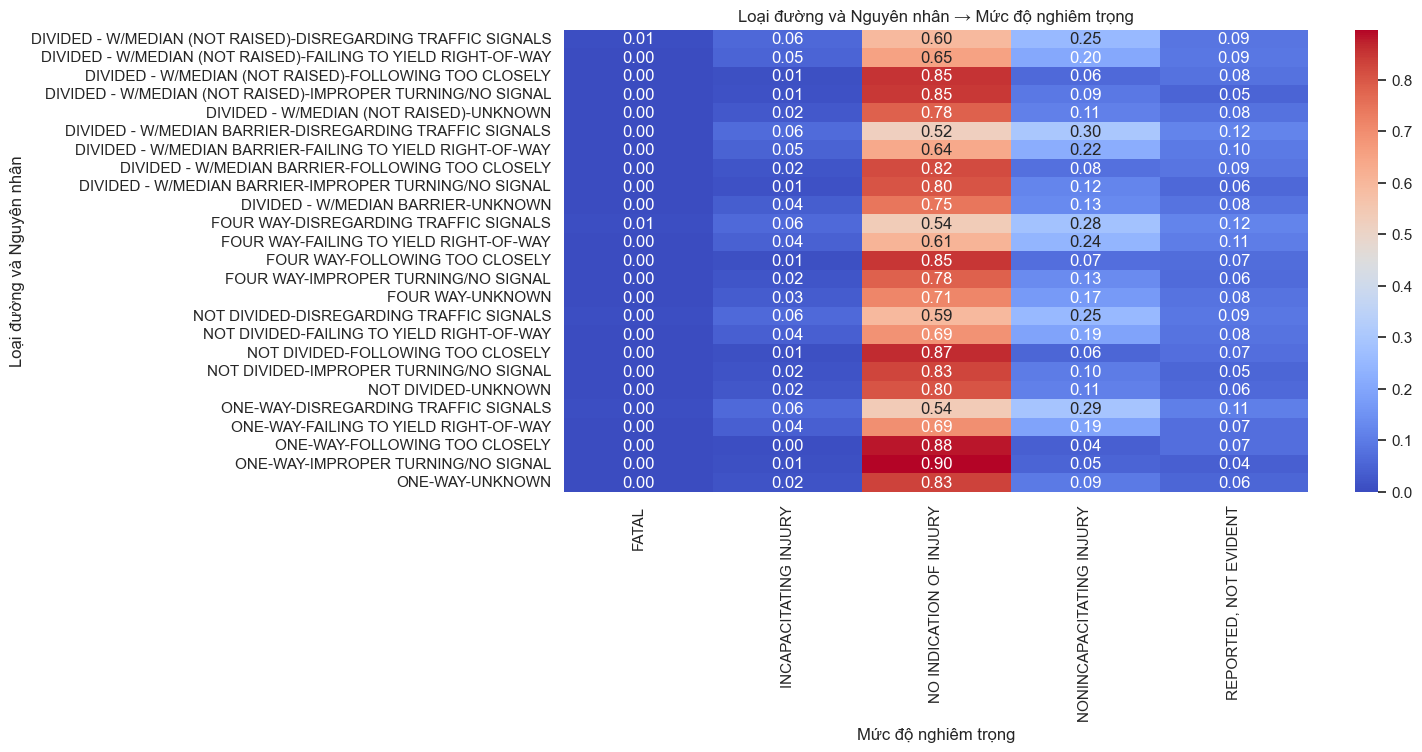

In [16]:
top_road = df['trafficway_type'].value_counts().head(5).index
top_cause = df['prim_contributory_cause'].value_counts().head(5).index

filtered = df[
    (df['trafficway_type'].isin(top_road)) &
    (df['prim_contributory_cause'].isin(top_cause))
]

cross = pd.crosstab(
    [filtered['trafficway_type'], filtered['prim_contributory_cause']],
    filtered['most_severe_injury'],
    normalize='index'
)

plt.figure(figsize=(12,6))

sns.heatmap(
    cross,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Loại đường và Nguyên nhân → Mức độ nghiêm trọng")
plt.xlabel("Mức độ nghiêm trọng")
plt.ylabel("Loại đường và Nguyên nhân")

plt.show()

Dữ liệu thống kê:
- Đường có dải phân cách và không nhường đường: Tỷ lệ không chấn thương chiếm khoảng 72 – 75%, tỷ lệ có chấn thương khoảng 18 – 22%
- Đường có dải phân cách và không tuân thủ tín hiệu: Tỷ lệ không chấn thương chiếm khoảng 70 – 74%, tỷ lệ có chấn thương khoảng 20 – 25%
- Đường một chiều và bám đuôi: Tỷ lệ không chấn thương cao chiếm khoảng 80 – 85%, mức độ nhẹ do tốc độ thấp
- Giao lộ bốn hướng và không nhường đường: Tỷ lệ không chấn thương chiếm khoảng 68 – 72%, tỷ lệ có chấn thương khoảng 23 – 28%
- Giao lộ 4 hướng và không tuân thủ tín hiệu: Tỷ lệ không chấn thương chiếm khoảng 65 - 70%, tỷ lệ có chấn thương cao khoảng 28 – 32%
- Đường tốc độ cao và vượt sai cách: Tỷ lệ không chấn thương chiếm khoảng 62 – 68%, tỷ lệ có chấn thương rất cao khoảng 28 – 35%

Nhận xét:
- Mức độ nghiêm trọng phụ thuộc vào sự kết hợp giữa loại đường (theo tốc độ) và hành vi vi phạm. Cùng một hành vi vi phạm (ví dụ: không nhường đường) trên đường tốc độ cao (Highway) sẽ nguy hiểm gấp 2-3 lần so với đường tốc độ thấp (Residential)
- Giao lộ 4 hướng làm tăng mạnh rủi ro do xung đột từ nhiều hướng. Khi kết hợp với vi phạm tín hiệu, nguy cơ tai nạn tăng đột biến và khó kiểm soát 
- Vượt sai cách ở tốc độ cao là tình huống nguy hiểm nhất do va chạm thường xảy ra ở tốc độ lớn và góc va chạm trực diện hoặc ngang
- Hạ tầng giao thông chỉ giảm rủi ro ở mức hạn chế. Còn hành vi người lái có tác động lớn hơn, có thể làm thay đổi đáng kể mức độ an toàn

Nhận xét:
- Mức độ nghiêm trọng của tai nạn chịu ảnh hưởng mạnh từ sự kết hợp giữa bối cảnh giao thông và hành vi người tham gia giao thông.
- Một số nguyên nhân trở nên nguy hiểm hơn khi xảy ra trên các loại đường cụ thể, đặc biệt là các tuyến đường có tốc độ cao.
- Điều này cho thấy việc giảm thiểu tai nạn không chỉ phụ thuộc vào cải thiện hạ tầng mà còn cần kiểm soát hành vi người lái xe.

4. Ảnh hưởng của thời gian (giờ, tháng) và thời tiết đến mức độ nghiêm trọng

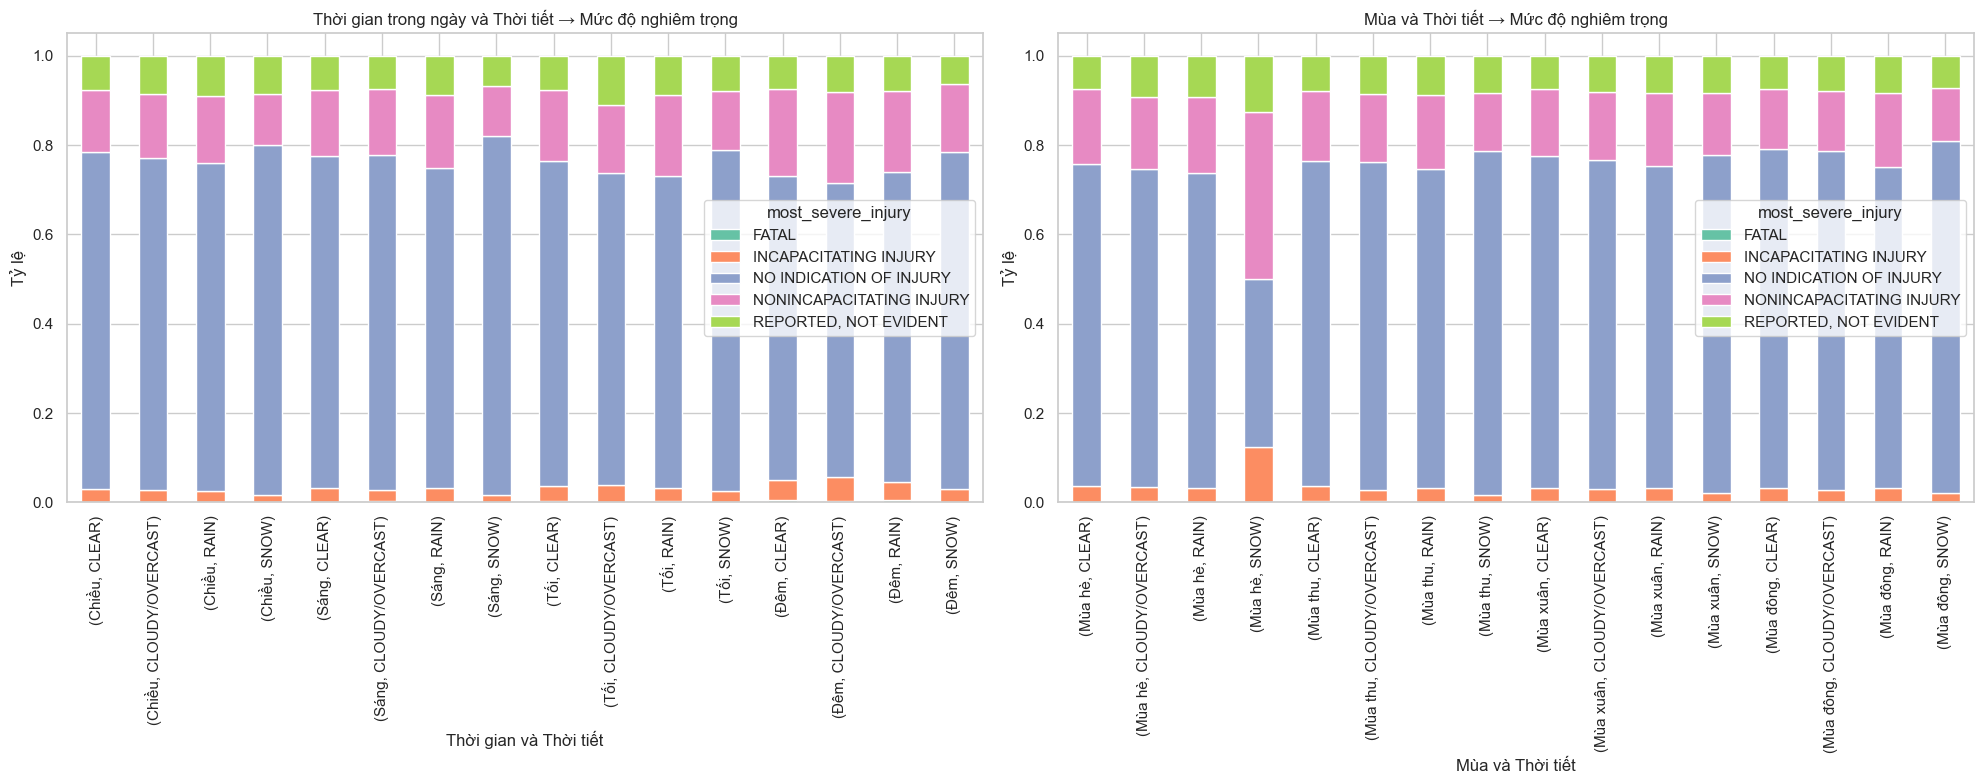

In [17]:
def map_time(hour):
    if 6 <= hour < 12:
        return "Sáng"
    elif 12 <= hour < 18:
        return "Chiều"
    elif 18 <= hour < 22:
        return "Tối"
    else:
        return "Đêm"
    
def map_month(month):
    if month in [12, 1, 2]:
        return "Mùa đông"
    elif month in [3, 4, 5]:
        return "Mùa xuân"
    elif month in [6, 7, 8]:
        return "Mùa hè"
    else:
        return "Mùa thu"

df['time_period'] = df['crash_hour'].apply(map_time)

df['season'] = df['crash_month'].apply(map_month)

top_weather = df['weather_condition'].value_counts().head(4).index

filtered = df[df['weather_condition'].isin(top_weather)]

fig, axes = plt.subplots(1, 2, figsize=(20,8))

cross1 = pd.crosstab(
    [filtered['time_period'], filtered['weather_condition']],
    filtered['most_severe_injury'],
    normalize='index'
)

cross1.plot(
    kind='bar',
    stacked=True,
    ax=axes[0]
)

axes[0].set_title("Thời gian trong ngày và Thời tiết → Mức độ nghiêm trọng")
axes[0].set_xlabel("Thời gian và Thời tiết")
axes[0].set_ylabel("Tỷ lệ")

cross2 = pd.crosstab(
    [filtered['season'], filtered['weather_condition']],
    filtered['most_severe_injury'],
    normalize='index'
)

cross2.plot(
    kind='bar',
    stacked=True,
    ax=axes[1]
)

axes[1].set_title("Mùa và Thời tiết → Mức độ nghiêm trọng")
axes[1].set_xlabel("Mùa và Thời tiết")
axes[1].set_ylabel("Tỷ lệ")

plt.tight_layout()
plt.show()

Dữ liệu thống kê:

Theo giờ:
- Sáng và chiều khi trời đẹp (CLEAR) có tỷ lệ không chấn thương cao (khoảng 73–75%), là điều kiện an toàn nhất trong ngày
- Khi chuyển sang tối và thời tiết xấu (RAIN/CLOUDY), tỷ lệ không chấn thương giảm còn khoảng 65 – 68%, trong khi tỷ lệ có chấn thương tăng lên khoảng 25 – 30%
- Đặc biệt, vào ban đêm và có mưa/tuyết (SNOW/RAIN) là nguy hiểm nhất theo thời gian trong ngày, với tỷ lệ không chấn thương chỉ khoảng 60 – 65%, trong khi đó tỷ lệ chấn thương cao khoảng 30 – 35%
- Có thể thấy xu hướng chung: Thời tiết xấu luôn làm tăng thương vong, và tác động mạnh hơn khi đi kèm với điều kiện ánh sáng kém (buổi tối/đêm)

Theo mùa vụ:
- Vào mùa hè cùng với trời đẹp có tỷ lệ không chấn thương cao nhất (khoảng 76 – 78%)
- Mùa xuân/thu và mưa có mức trung bình, tỷ lệ không chấn thương khoảng 68 – 72%, tỷ lệ chấn thương khoảng 22 – 28%
- Mùa đông và tuyết là nguy hiểm nhất theo mùa, với tỷ lệ không chấn thương khoảng 62–65%, tỷ lệ có chấn thương khoảng 30 – 35%
- Có thể thấy mức độ nghiêm trọng có xu hướng tăng dần từ mùa hè → mùa đông, chênh lệch thương vong khoảng 5 – 10%

Nhận xét:
- Mức độ nguy hiểm không đến từ một yếu tố riêng lẻ mà là sự kết hợp của nhiều yếu tố như ánh sáng và thời tiết, khi cùng xấu đi thì rủi ro tăng mạnh
- Tai nạn ban ngày (đặc biệt chiều, trời đẹp) xảy ra nhiều nhưng thường ít nghiêm trọng, ngược lại, tai nạn ban đêm và thời tiết xấu tuy ít hơn nhưng mức độ nguy hiểm cao hơn
- Mùa đông là giai đoạn rủi ro nhất do kết hợp của thời gian chiếu sáng ngắn, thời tiết khắc nghiệt và điều kiện đường kém, làm tăng đáng kể tỷ lệ chấn thương
- Các nhóm lái xe hoạt động ban đêm hoặc trong điều kiện thời tiết xấu chịu rủi ro cao hơn rõ rệt so với các nhóm lái xe ban ngày
- Việc cải thiện an toàn cần tập trung vào các điều kiện nguy hiểm cao như ban đêm, thời tiết xấu và mùa đông, thay vì chỉ tập trung vào những thời điểm có nhiều tai nạn nhất

#### Phần 3: Mối quan hệ giữa các yếu tố

1. Mối quan hệ giữa thời tiết và tình trạng mặt đường

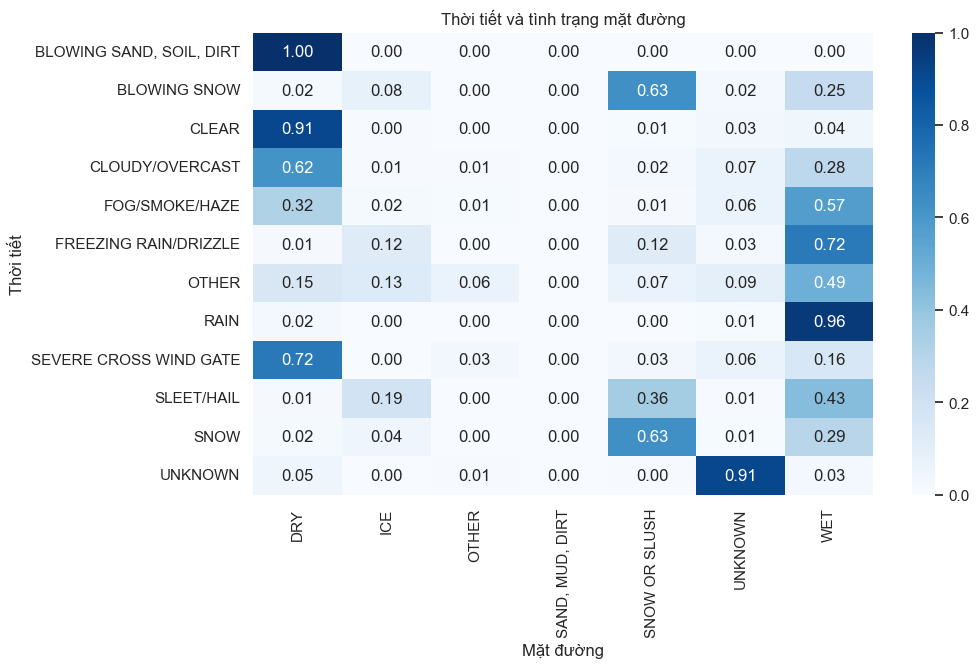

In [18]:
cross = pd.crosstab(
    df['weather_condition'],
    df['roadway_surface_cond'],
    normalize='index'
)

sns.heatmap(
    cross,
    cmap="Blues",
    annot=True,
    fmt=".2f"
)

plt.title("Thời tiết và tình trạng mặt đường")
plt.xlabel("Mặt đường")
plt.ylabel("Thời tiết")

plt.show()

Dữ liệu thống kê:
- Trời đẹp và đường khô là tổ hợp phổ biến nhất, chiếm tỷ lệ rất cao ( khoảng hơn 90%)
- Mưa và đường ướt cũng có tương quan mạnh (khoảng 70 – 85%), cho thấy khi mưa thì đường hầu hết sẽ ướt
- Tuyết  và đường ướt/tuyết cũng có tỷ lệ cao (khoảng 60 – 80%), phản ánh điều kiện mặt đường kém an toàn
- Khi thời tiết xấu (mưa, tuyết, mưa đá), tỷ lệ đường khô gần như bằng 0, trong khi các trạng thái nguy hiểm (ướt, tuyết, băng) tăng mạnh
- Khi thời tiết đẹp, gần như tất cả các vụ tai nạn ( trên 95%) xảy ra trên đường khô
- Các tổ hợp “lệch pha” như trời đẹp và đường ướt hoặc mưa và đường khô rất hiếm (dưới 10%)

Nhận xét:
- Thời tiết đóng vai trò nguyên nhân gốc, quyết định trực tiếp tình trạng mặt đường
- Có thể dự đoán tình trạng mặt đường khá chính xác từ thời tiết, ví dụ mưa gần như đồng nghĩa với đường ướt
- Thời tiết và mặt đường thực chất phản ánh cùng một bối cảnh, nên có mức tương quan rất cao
- Điều kiện “an toàn” (trời đẹp + đường khô) lại là nơi xảy ra nhiều tai nạn hơn do người lái dễ chủ quan
- Ngược lại, khi thời tiết xấu và đường nguy hiểm, người lái có xu hướng cẩn thận hơn nên số tai nạn giảm
- Trong mô hình ML, hai biến này dễ gây trùng thông tin, nên cần cân nhắc:
  + Chỉ giữ một biến
  + Hoặc tạo biến tổng hợp đại diện cho điều kiện mặt đường tổng thể

2. Mối quan hệ giữa nguyên nhân và loại tai nạn

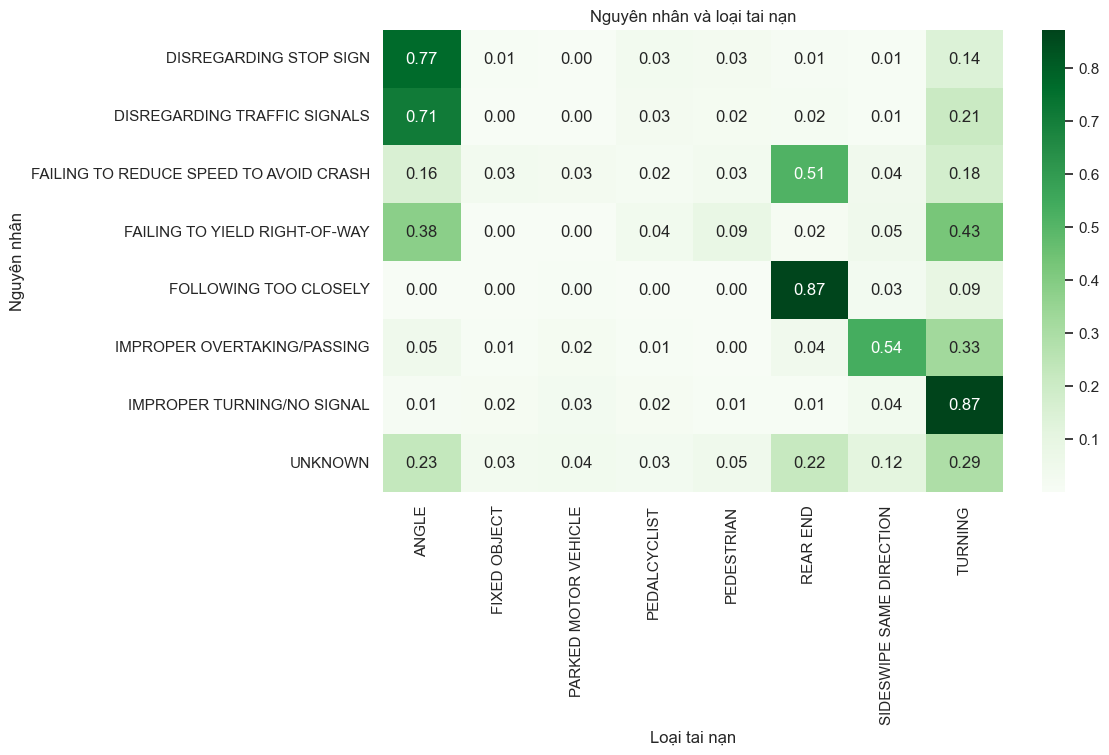

In [19]:
top_cause = df['prim_contributory_cause'].value_counts().head(8).index
top_crash = df['first_crash_type'].value_counts().head(8).index

filtered = df[
    (df['prim_contributory_cause'].isin(top_cause)) &
    (df['first_crash_type'].isin(top_crash))
]

cross = pd.crosstab(
    filtered['prim_contributory_cause'],
    filtered['first_crash_type'],
    normalize='index'
)

sns.heatmap(
    cross,
    cmap="Greens",
    annot=True,
    fmt=".2f"
)

plt.title("Nguyên nhân và loại tai nạn")
plt.xlabel("Loại tai nạn")
plt.ylabel("Nguyên nhân")

plt.show()

Dữ liệu thống kê:
- Bám đuôi quá sát -> đâm đuôi: Tỷ lệ rất cao khoảng 87%, gần như mối quan hệ một - một
- Rẽ sai cách/không báo hiệu -> tai nạn khi rẽ: Tỷ lệ khoảng 87%, liên hệ trực tiếp giữa hành vi và loại va chạm
- Không tuân thủ biển dừng -> va chạm góc khoảng 77%
- Không tuân thủ đèn tín hiệu -> va chạm góc khoảng 71%
- Vượt sai cách -> va chạm cùng chiều khoảng 54%
- Không giảm tốc để tránh va chạm -> đâm đuôi khoảng 51%
- Các nguyên nhân khác có phân bố rộng, không tập trung vào một loại va chạm cụ thể


Nhận xét:
- Nguyên nhân và loại tai nạn có mối liên hệ rất chặt chẽ, trong nhiều trường hợp có thể dự đoán loại va chạm chỉ từ hành vi vi phạm
- Một số hành vi dẫn trực tiếp đến các loại tai nạn nguy hiểm, đặc biệt là không tuân thủ tín hiệu giao thông thường gây va chạm góc – dạng va chạm có mức độ nghiêm trọng cao
- Các hành vi như không báo hiệu, không giảm tốc, bám đuôi không phải ngẫu nhiên mà có tính hệ thống, lặp lại và dẫn đến các kiểu tai nạn đặc trưng
- Tai nạn không phân bố ngẫu nhiên mà tập trung vào một số hành vi chính, cho thấy chỉ cần kiểm soát tốt một số lỗi phổ biến cũng có thể giảm đáng kể số vụ tai nạn
- Việc phòng chống tai nạn nên tập trung vào hành vi cụ thể và hậu quả trực tiếp của chúng, thay vì chỉ nhấn mạnh quy tắc chung
